In [42]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sbi.analysis import pairplot
import yaml
import scipy

# Import local packages
from examples.unif_norm import (
    prior_pdf,
    get_approximate_posterior_density,
    true_posterior_pdf,
    approximate_posterior_quantiles_against_x,
    plot_approximate_posterior_quantiles_against_x,
    plot_approximate_posterior_quantiles_diff_against_x,
    plot_leakage_factors
)
from sbc.sbc_tools import plot_sbc_all
algorithm_names = ["npe_c", "tsnpe", "nle_mcmc", "nle_vi", "nre"]
algorithm_names_to_nice = {"npe_c": "SNPE-C",
                                  "tsnpe": "TSNPE",
                                  "nle_mcmc": "SNLE-MCMC",
                                  "nle_vi": "SNLE-VI",
                                  "nre": "SNRE-B"}
algorithm_KLs_squared_norms_ID = {"npe_c": [2,1,0,3,5,4],
                                  "tsnpe": [1,2,0,7,np.nan,np.nan],
                                  "nle_mcmc": [2,1,0,5,6,7],
                                  "nle_vi": [2,1,0,6,8,9],
                                  "nre": [3,2,1,6,7,8]} # Maps each algo to the experiment IDs of the d=3,10,25,50,100 experiments, respectively.
d_list = [3,10,25,50,75,100]

In [43]:
KLs_dicts = {algorithm_name : [] for algorithm_name in algorithm_names}
KLs_squared_norms_configs = {algorithm_name : [] for algorithm_name in algorithm_names}

for algorithm_name in algorithm_names:
    KLs_squared_norms_IDs = algorithm_KLs_squared_norms_ID[algorithm_name] # List of experiment IDs
    for i, experiment_ID in enumerate(KLs_squared_norms_IDs):
        if not np.isnan(experiment_ID): # Ignore unfinished experiments
            d = d_list[i]
            results_path = "/Users/Lieve/Documents/Masters Project/SBC-SBI/results/toy_examples/unif_norm" + f"/{algorithm_name}/"
            config_path = results_path + f"KLs_squared_norms{experiment_ID}.yaml"
            KLs_path = results_path + f"KLs_squared_norms{experiment_ID}_KLs_dict.npz"

            # Load config
            with open(config_path, "r") as f:
                KLs_squared_norms_config = yaml.safe_load(f)
            KLs_squared_norms_configs[algorithm_name].append(KLs_squared_norms_config)

            # Load squared norms
            KLs_dict = dict(np.load(KLs_path))
            KLs_dicts[algorithm_name].append(KLs_dict["round_7"]) # Append final round KL

In [44]:
KLs_dicts["tsnpe"]

[array([0.02179845, 0.02362653, 0.02114736, 0.02527699, 0.01711336,
        0.02244099, 0.01520133, 0.01143588, 0.02473382, 0.02798029]),
 array([1.08650243, 1.16841793, 1.10532641, 1.01171148, 1.04649746,
        0.98014843, 1.05607581, 1.06190002, 0.9753384 , 1.1429342 ]),
 array([3.8068614 , 3.46977139, 3.74173594, 3.7347343 , 3.52830791,
        3.6467886 , 3.70676994, 3.61623907, 3.86031008, 3.62871099]),
 array([6.71079683, 6.63806725, 6.58822346, 6.50611973, 6.47872257,
        6.23289442, 7.66316414, 6.7966361 , 6.82996273, 7.02568913])]

In [50]:
def plot_KL_against_d(KLs_dicts, exclude_methods=None, title=None):
    if exclude_methods is None:
        exclude_methods = []

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.set_xlabel(r"Dimension $d$")
    ax.set_ylabel(r"$KL\left(\tilde{\pi} || \pi\right)$")
    if title is None:
        ax.set_title("KL divergence between approximate posterior and true posterior in various dimensions")
    else:
        ax.set_title(title)

    # Loop over algorithms
    for method_name, KLs_list in KLs_dicts.items():
        if method_name not in exclude_methods:
            mean_KLs = []
            #SE_KLs = []
            LQ_KLs = []
            UQ_KLs = []
            ds = []
            for i, KLs_array in enumerate(KLs_dicts[method_name]): # KLs_array is an array of size (num_repetitions, )
                d = d_list[i]
                ds.append(d)
                num_repetitions = len(KLs_array)
                mean_KL = np.mean(KLs_array)
                mean_KLs.append(mean_KL)
                #SE_KL = np.std(KLs_array, ddof=1) / np.sqrt(num_repetitions)
                #SE_KLs.append(SE_KL)
                LQ_KL = np.quantile(KLs_array, 0.05)
                LQ_KLs.append(LQ_KL)     
                UQ_KL = np.quantile(KLs_array, 0.95)
                UQ_KLs.append(UQ_KL)
            
            mean_KLs = np.array(mean_KLs)
            #SE_KLs = np.array(SE_KLs)
            LQ_KLs = np.array(LQ_KLs)
            UQ_KLs = np.array(UQ_KLs)

            # Plot mean line
            line, = ax.plot(ds, mean_KLs, label=r"Mean KL (with $q_{0.05}$ and $q_{0.95}$) for " + f"{algorithm_names_to_nice[method_name]}")

            # Shaded +-1 SE band
            ax.fill_between(
                ds,
                #mean_KLs - 2 * SE_KLs,
                #mean_KLs + 2 * SE_KLs,
                LQ_KLs,
                UQ_KLs,
                alpha=0.2,
                color=line.get_color(),
            )

    #ax.set_xlim(0, 76)
    ax.legend()
    plt.tight_layout()
    ax.set_yscale("log")
    plt.show()


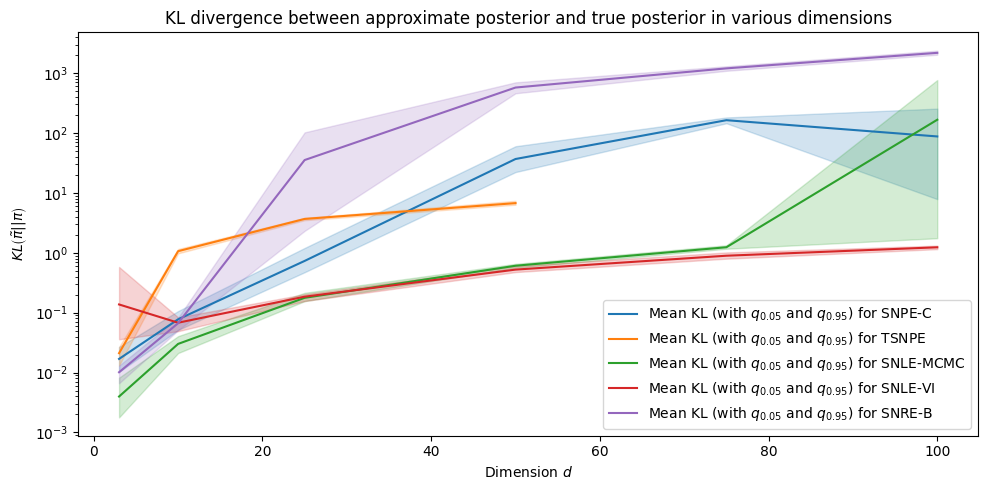

In [52]:
plot_KL_against_d(KLs_dicts, exclude_methods=[], title=None)